Modelo RandomForest treinado com sucesso.
corte: 0.5119482800602215
Acurácia da RandomForest: 0.7067
=== Relatório de Classificação ===
              precision    recall  f1-score   support

           0       0.97      0.68      0.80   1024603
           1       0.30      0.88      0.45    160369

    accuracy                           0.71   1184972
   macro avg       0.64      0.78      0.62   1184972
weighted avg       0.88      0.71      0.75   1184972

roc: 0.8582463348248734


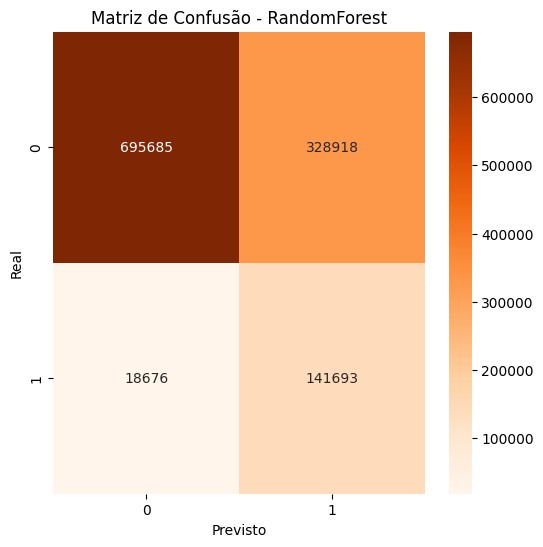

Taxa prevista pelo modelo: 0.397
Taxa real na base: 0.135
Top variáveis mais importantes:


,Variavel,Importancia
0,opcao_curso_2,0.386414
1,opcao_curso_3,0.306246
2,renda_per_capita,0.073544
3,renda_gap,0.044619
4,gap,0.030159
5,"subarea_conhecimento_ODONTOLOGIA, QUIROPRAXIA,...",0.023524
6,nota_corte_gp,0.020936
7,idade,0.017208
8,conceito_curso_gp_5,0.013451
9,ensino_medio_escola_publica_SIM,0.011012


Todas as importâncias:


,Variavel,Importancia
0,opcao_curso_2,0.386414
1,opcao_curso_3,0.306246
2,renda_per_capita,0.073544
3,renda_gap,0.044619
4,gap,0.030159
...,...,...
65,modalidade_fies_eliminado,0.000000
66,beneficiado_creduc_fies_SIM,0.000000
67,modalidade_fies_Modalidade II,0.000000
68,"subarea_conhecimento_AGRONEGÓCIO, AGROINDÚSTRI...",0.000000


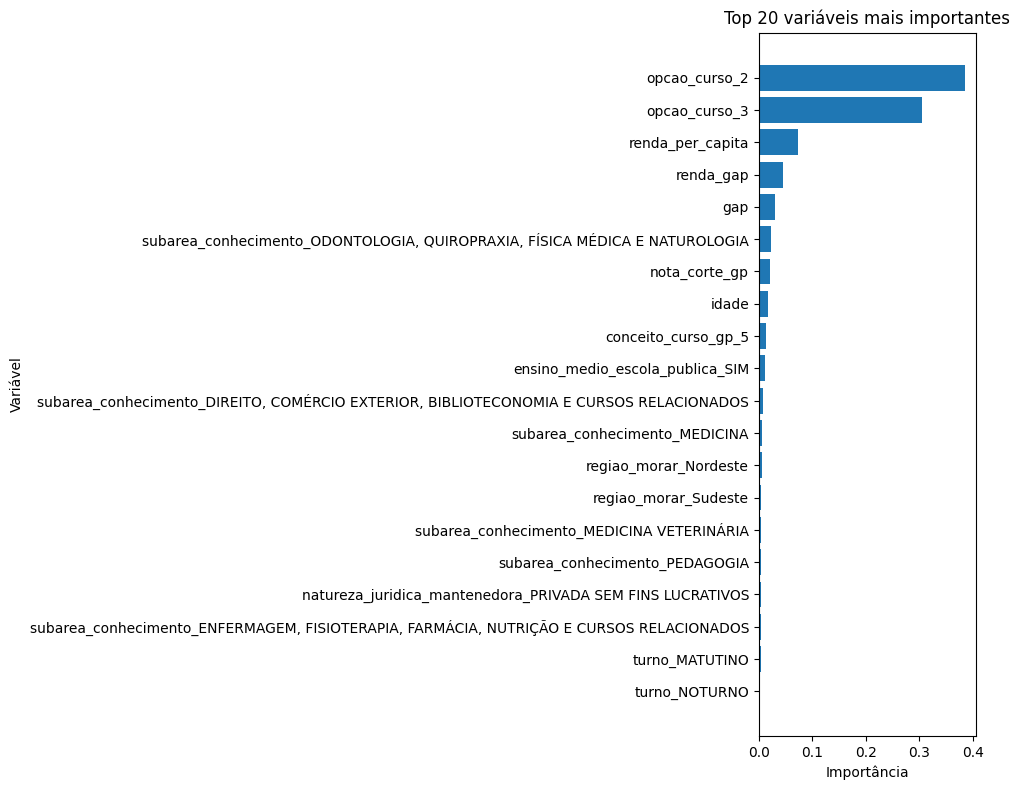


[INFO] Gráfico 1: impacto da NOTA dependendo da RENDA
[INFO] Cada linha fixa uma renda e mostra como a probabilidade varia com o gap
[INFO] Linha azul (0.5 = 50%) é o limiar de decisão do modelo


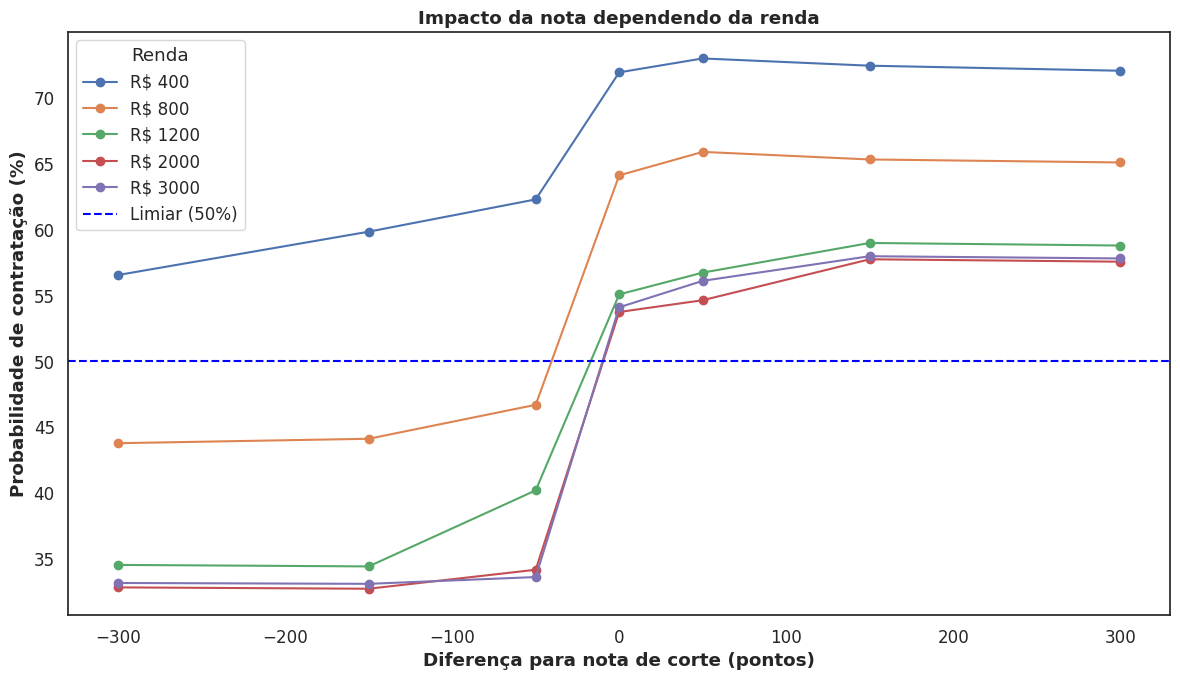


[INFO] Gráfico 2: impacto da RENDA dependendo da NOTA
[INFO] Cada linha fixa um gap e mostra como a probabilidade varia com a renda


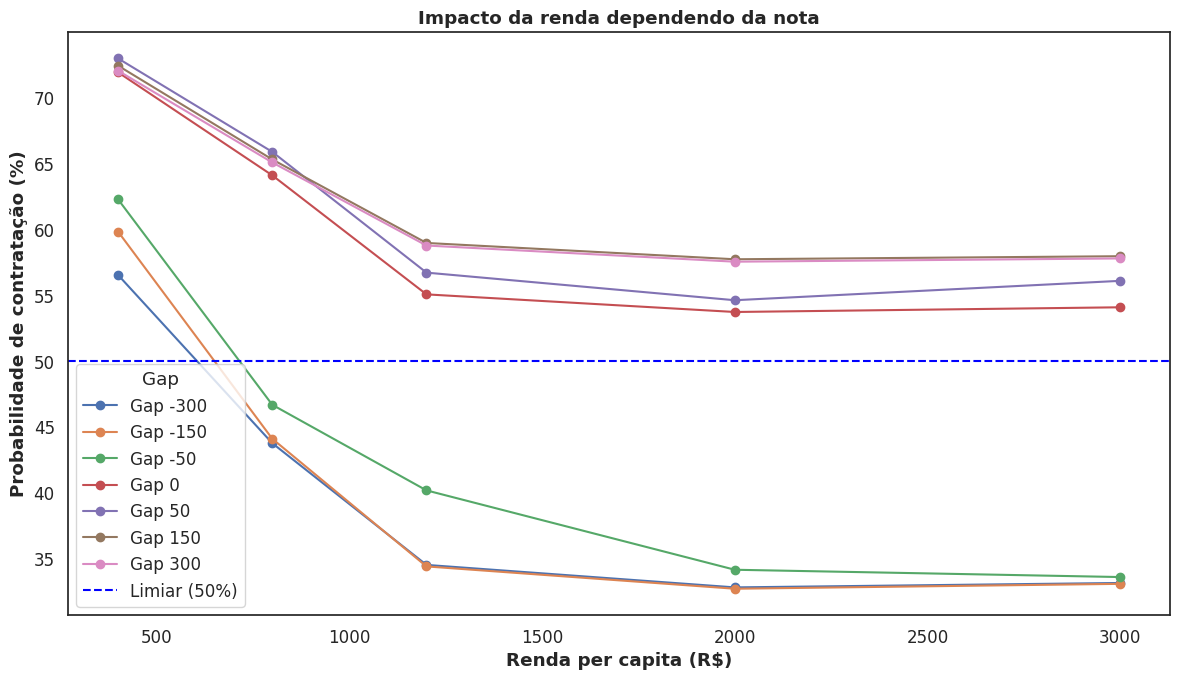


[INFO] Heatmap: visão consolidada renda × nota


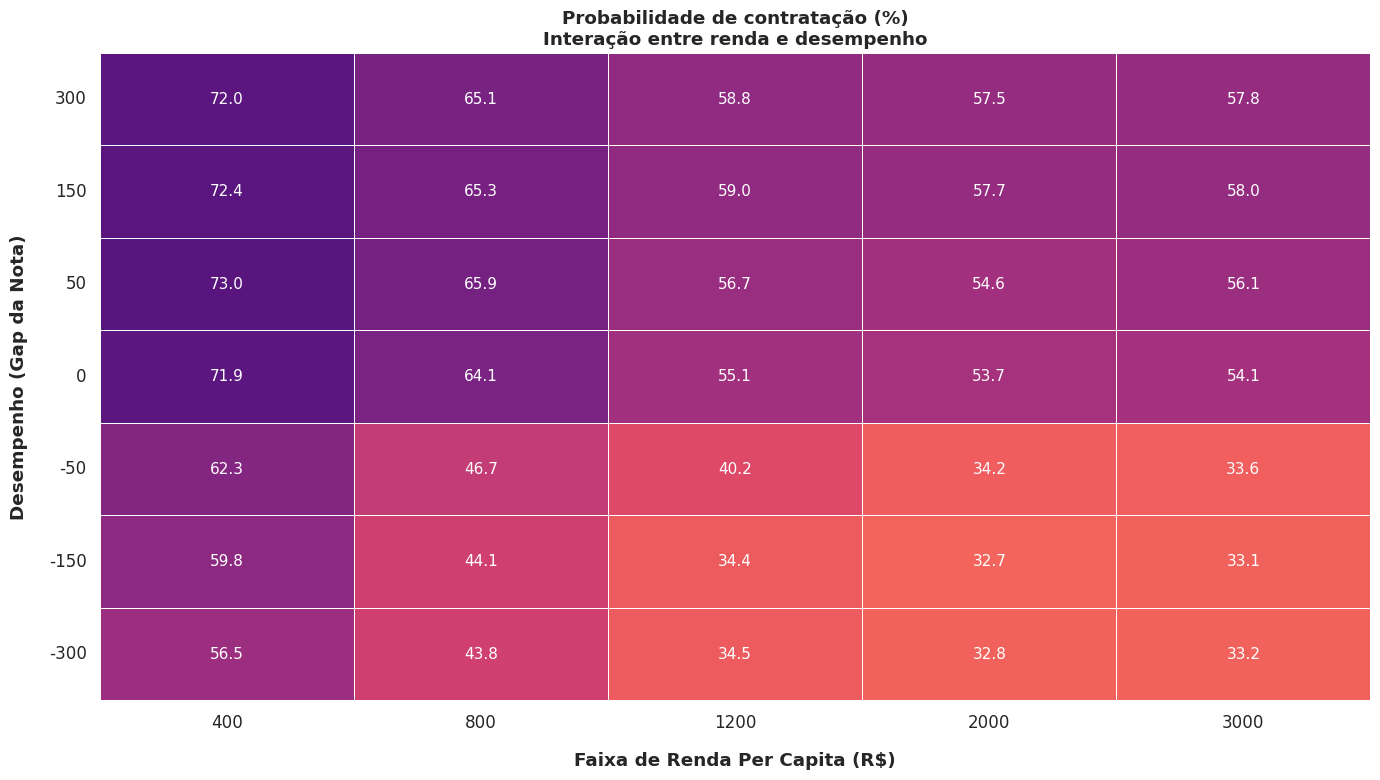


🧠 INTERPRETAÇÃO COMPLETA — RANDOM FOREST (ANÁLISE 017)

📊 IMPORTÂNCIA DAS VARIÁVEIS (TOP 10):
                                             variavel  importancia
10                                      opcao_curso_2     0.386414
11                                      opcao_curso_3     0.306246
0                                    renda_per_capita     0.073544
4                                           renda_gap     0.044619
1                                                 gap     0.030159
45  subarea_conhecimento_ODONTOLOGIA, QUIROPRAXIA,...     0.023524
3                                       nota_corte_gp     0.020936
2                                               idade     0.017208
14                                conceito_curso_gp_5     0.013451
69                    ensino_medio_escola_publica_SIM     0.011012

🔎 FOCO NAS VARIÁVEIS-CHAVE:
 - renda_per_capita: 0.0735
 - gap:              0.0302
 - renda_gap:        0.0446

📌 INTERPRETAÇÃO DAS IMPORTÂNCIAS:

- A Random Forest N

In [ ]:
# RANDOM FOREST — classificação binária
# Base inteira 2019 a 2021
# Objetivo: captar não linearidade e interação entre renda_per_capita e gap

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
from sklearn.inspection import PartialDependenceDisplay
from sklearn.tree import plot_tree, export_text
from IPython.display import display
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from constantes import (
    pasta_data_05_processed_analise_017_X_treino, 
    pasta_data_05_processed_analise_017_y_treino,
    pasta_data_04_load_inscritos
)

# =========================================================
# 1) CARREGAR DADOS
# =========================================================

X_treino = pd.read_parquet(str(pasta_data_05_processed_analise_017_X_treino))
Y_treino = pd.read_parquet(str(pasta_data_05_processed_analise_017_y_treino)).values.ravel()

# usando a base inteira na avaliação
X_teste = X_treino.copy()
y_teste = Y_treino.copy()

# =========================================================
# 2) TREINAR MODELO
# =========================================================

max_depth = 42

modelo = RandomForestClassifier(
    max_depth=max_depth,
    n_estimators=1000,
    n_jobs=-1,
    class_weight='balanced',
    random_state=42,
    min_samples_leaf=125,
    max_features='sqrt'
)

modelo.fit(X_treino, Y_treino)

print("Modelo RandomForest treinado com sucesso.")

# =========================================================
# 3) VISUALIZAR UMA ÁRVORE DA FLORESTA (OPCIONAL)
# =========================================================

visualizar_arvore = 'nao'

if visualizar_arvore == 'sim':
    arvore = modelo.estimators_[0]

    plt.figure(figsize=(40, 20))
    plot_tree(
        arvore,
        feature_names=list(X_treino.columns),
        class_names=['Não Contratado', 'Contratado'],
        filled=True,
        rounded=True,
        fontsize=8,
        max_depth=3
    )
    plt.show()

    regras_arvore = export_text(
        arvore,
        feature_names=list(X_treino.columns),
        max_depth=3
    )
    print(regras_arvore)

# =========================================================
# 4) AVALIAÇÃO NA MESMA BASE
# =========================================================

y_probs = modelo.predict_proba(X_teste)[:, 1]

fpr, tpr, thresholds = roc_curve(y_teste, y_probs)
melhor_indice = (tpr - fpr).argmax()
threshold = thresholds[melhor_indice]
corte = threshold

print("corte:", corte)

y_predict = (y_probs >= threshold).astype(int)

acuracia = accuracy_score(y_teste, y_predict)
roc = roc_auc_score(y_teste, y_probs)

print(f"Acurácia da RandomForest: {acuracia:.4f}")
print("=== Relatório de Classificação ===")
print(classification_report(y_teste, y_predict))
print("roc:", roc)

matriz = confusion_matrix(y_teste, y_predict)

plt.figure(figsize=(6, 6))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Oranges')
plt.title("Matriz de Confusão - RandomForest")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

print(f"Taxa prevista pelo modelo: {y_predict.mean():.3f}")
print(f"Taxa real na base: {y_teste.mean():.3f}")

# =========================================================
# 5) IMPORTÂNCIA DAS VARIÁVEIS
# =========================================================

df_importancias = pd.DataFrame({
    'Variavel': X_treino.columns,
    'Importancia': modelo.feature_importances_
}).sort_values(by='Importancia', ascending=False).reset_index(drop=True)

filtro = df_importancias['Importancia'] > 0

print("Top variáveis mais importantes:")
display(df_importancias[filtro].head(30))

print("Todas as importâncias:")
display(df_importancias)

plt.figure(figsize=(10, 8))
top20 = df_importancias.head(20).sort_values("Importancia")
plt.barh(top20["Variavel"], top20["Importancia"])
plt.title("Top 20 variáveis mais importantes")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.tight_layout()
plt.show()

# =========================================================
# 6) LEITURA DE INTERAÇÃO RENDA × GAP
# =========================================================

def analise_real_renda_gap_rf(modelo, X_ref):
    from pathlib import Path
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    # ==============================================================================
    # 1. CONFIGURAÇÕES (PADRÃO VISUAL)
    # ==============================================================================

    sns.set_theme(style="white", font_scale=1.1)

    pasta_figuras = Path('reports/figures/analise_017').resolve()
    pasta_figuras.mkdir(parents=True, exist_ok=True)

    # ==============================================================================
    # 2. GRID CONTROLADO (INTERPRETÁVEL)
    # ==============================================================================

    rendas = [400, 800, 1200, 2000, 3000]
    gaps = [-300, -150, -50, 0, 50, 150, 300]

    valores_medios = X_ref.mean(numeric_only=True)
    mediana_idade = X_ref['idade'].median()
    mediana_nota_corte = X_ref['nota_corte_gp'].median()

    linhas = []

    for renda in rendas:
        for gap in gaps:

            linha = {}

            for col in X_ref.columns:
                if col == 'renda_per_capita':
                    linha[col] = renda
                elif col == 'gap':
                    linha[col] = gap
                elif col == 'renda_gap':
                    linha[col] = renda * gap
                elif col == 'idade':
                    linha[col] = mediana_idade
                elif col == 'nota_corte_gp':
                    linha[col] = mediana_nota_corte
                else:
                    linha[col] = valores_medios.get(col, 0)

            linhas.append(linha)

    df_real = pd.DataFrame(linhas).reindex(columns=X_ref.columns, fill_value=0)

    # ==============================================================================
    # 3. PREDIÇÃO
    # ==============================================================================

    probs = modelo.predict_proba(df_real)[:, 1]
    df_real['prob'] = probs * 100  # 🔥 PADRÃO EM %

    # ==============================================================================
    # 4. CURVAS — IMPACTO DA NOTA DEPENDENDO DA RENDA
    # ==============================================================================

    print("\n[INFO] Gráfico 1: impacto da NOTA dependendo da RENDA")
    print("[INFO] Cada linha fixa uma renda e mostra como a probabilidade varia com o gap")
    print("[INFO] Linha azul (0.5 = 50%) é o limiar de decisão do modelo")

    plt.figure(figsize=(12, 7))

    for renda in rendas:
        subset = df_real[df_real['renda_per_capita'] == renda].sort_values('gap')

        plt.plot(
            subset['gap'],
            subset['prob'],
            marker='o',
            label=f'R$ {renda}'
        )

    plt.axhline(50, color='blue', linestyle='--', label='Limiar (50%)')

    plt.xlabel('Diferença para nota de corte (pontos)', fontweight='bold')
    plt.ylabel('Probabilidade de contratação (%)', fontweight='bold')
    plt.title('Impacto da nota dependendo da renda', fontweight='bold')

    plt.legend(title='Renda')
    plt.tight_layout()
    plt.savefig(pasta_figuras / 'rf_curvas_nota_por_renda.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ==============================================================================
    # 5. CURVAS — IMPACTO DA RENDA DEPENDENDO DA NOTA
    # ==============================================================================

    print("\n[INFO] Gráfico 2: impacto da RENDA dependendo da NOTA")
    print("[INFO] Cada linha fixa um gap e mostra como a probabilidade varia com a renda")

    plt.figure(figsize=(12, 7))

    for gap in gaps:
        subset = df_real[df_real['gap'] == gap].sort_values('renda_per_capita')

        plt.plot(
            subset['renda_per_capita'],
            subset['prob'],
            marker='o',
            label=f'Gap {gap}'
        )

    plt.axhline(50, color='blue', linestyle='--', label='Limiar (50%)')

    plt.xlabel('Renda per capita (R$)', fontweight='bold')
    plt.ylabel('Probabilidade de contratação (%)', fontweight='bold')
    plt.title('Impacto da renda dependendo da nota', fontweight='bold')

    plt.legend(title='Gap')
    plt.tight_layout()
    plt.savefig(pasta_figuras / 'rf_curvas_renda_por_nota.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ==============================================================================
    # 6. HEATMAP — PADRÃO ABNT (RENDA × NOTA)
    # ==============================================================================

    print("\n[INFO] Heatmap: visão consolidada renda × nota")

    ordem_gap = gaps[::-1]  # 🔥 alto desempenho em cima

    matriz = df_real.pivot(
        index='gap',
        columns='renda_per_capita',
        values='prob'
    ).reindex(index=ordem_gap, columns=rendas)

    plt.figure(figsize=(14, 8))

    sns.heatmap(
        matriz,
        annot=True,
        fmt=".1f",
        cmap="magma_r",
        vmin=0,
        vmax=100,
        linewidths=0.5,
        linecolor='white',
        annot_kws={"size": 11},
        cbar=False
    )

    plt.ylabel('Desempenho (Gap da Nota)', fontweight='bold', labelpad=15)
    plt.xlabel('Faixa de Renda Per Capita (R$)', fontweight='bold', labelpad=15)

    plt.xticks(rotation=0)
    plt.yticks(rotation=0)

    plt.title(
        'Probabilidade de contratação (%)\nInteração entre renda e desempenho',
        fontweight='bold'
    )

    plt.tight_layout()
    plt.savefig(pasta_figuras / 'rf_heatmap_renda_nota.png', dpi=300, bbox_inches='tight')
    plt.show()

analise_real_renda_gap_rf(modelo, X_treino)


# =========================================================
# 8) INTERPRETAÇÃO COMPLETA DO MODELO (PRINT EXPLICATIVO)
# =========================================================

def interpretacao_modelo_random_forest(modelo, X):

    import pandas as pd
    import numpy as np

    print("\n" + "="*80)
    print("🧠 INTERPRETAÇÃO COMPLETA — RANDOM FOREST (ANÁLISE 017)")
    print("="*80)

    # =====================================================
    # 1. IMPORTÂNCIAS DAS VARIÁVEIS
    # =====================================================

    df_imp = pd.DataFrame({
        'variavel': X.columns,
        'importancia': modelo.feature_importances_
    }).sort_values(by='importancia', ascending=False)

    print("\n📊 IMPORTÂNCIA DAS VARIÁVEIS (TOP 10):")
    print(df_imp.head(10))

    # pegar principais
    imp_renda = df_imp[df_imp['variavel'] == 'renda_per_capita']['importancia'].values
    imp_gap = df_imp[df_imp['variavel'] == 'gap']['importancia'].values
    imp_inter = df_imp[df_imp['variavel'] == 'renda_gap']['importancia'].values

    imp_renda = imp_renda[0] if len(imp_renda) else 0
    imp_gap = imp_gap[0] if len(imp_gap) else 0
    imp_inter = imp_inter[0] if len(imp_inter) else 0

    print("\n🔎 FOCO NAS VARIÁVEIS-CHAVE:")
    print(f" - renda_per_capita: {imp_renda:.4f}")
    print(f" - gap:              {imp_gap:.4f}")
    print(f" - renda_gap:        {imp_inter:.4f}")

    # =====================================================
    # 2. INTERPRETAÇÃO DAS IMPORTÂNCIAS
    # =====================================================

    print("\n📌 INTERPRETAÇÃO DAS IMPORTÂNCIAS:")

    print("""
- A Random Forest NÃO usa coeficientes lineares.
- Aqui, a "importância" mede o quanto cada variável ajuda a reduzir erro nas árvores.

👉 Quanto maior a importância:
   MAIS o modelo depende daquela variável para decidir.
""")

    if imp_inter > imp_renda and imp_inter > imp_gap:
        print("🔥 PRINCIPAL DRIVER: INTERAÇÃO (renda × gap)")
    elif imp_gap > imp_renda:
        print("🔥 PRINCIPAL DRIVER: desempenho (gap)")
    else:
        print("🔥 PRINCIPAL DRIVER: renda")

    # =====================================================
    # 3. INTERPRETAÇÃO ECONÔMICA (O QUE O MODELO APRENDEU)
    # =====================================================

    print("\n📊 LEITURA ECONÔMICA DO MODELO:")

    print("""
O modelo está aprendendo regras do tipo:

- "Se renda é alta E nota é boa → alta chance de contratação"
- "Se renda é baixa E nota ruim → baixa chance"
- "Se renda é baixa mas nota é MUITO boa → pode compensar"
- "Se renda é alta mas nota é ruim → pode ainda passar dependendo do corte"

👉 Isso é NÃO-LINEARIDADE + INTERAÇÃO.
""")

    # =====================================================
    # 4. INTERPRETAÇÃO DOS GRÁFICOS
    # =====================================================

    print("\n📈 INTERPRETAÇÃO DOS GRÁFICOS GERADOS:")

    print("""
1) CURVAS (nota dependendo da renda):
   - Cada linha = uma renda fixa
   - Mostra como a nota (gap) impacta a chance

   👉 Se as curvas forem separadas:
      → renda altera o efeito da nota (INTERAÇÃO)

2) CURVAS (renda dependendo da nota):
   - Cada linha = um nível de desempenho
   - Mostra como renda impacta a chance

   👉 Se curvas não forem paralelas:
      → efeito da renda depende da nota

3) HEATMAP:
   - Visão mais importante
   - Cada célula = probabilidade do modelo

   👉 Leitura correta:
      - canto superior direito = melhor cenário
      - canto inferior esquerdo = pior cenário

   👉 Se o gradiente for diagonal:
      → modelo depende dos DOIS (renda + nota)

   👉 Se for mais horizontal:
      → gap domina

   👉 Se for mais vertical:
      → renda domina
""")

    # =====================================================
    # 5. DIFERENÇA PRA REGRESSÃO LOGÍSTICA
    # =====================================================

    print("\n⚖️ RANDOM FOREST vs REGRESSÃO LOGÍSTICA:")

    print("""
REGRESSÃO LOGÍSTICA:
- Linear
- Interpretação via coeficiente
- Interação explícita (renda_gap)

RANDOM FOREST:
- Não linear
- Interação automática
- Capta regras complexas tipo:
    "se renda > X E gap > Y então..."

👉 Ou seja:
RF é mais realista, mas menos interpretável direto.
""")

    # =====================================================
    # 6. CONCLUSÃO FINAL (NÍVEL EXECUTIVO)
    # =====================================================

    print("\n🏁 CONCLUSÃO FINAL:")

    print(f"""
- Importância renda: {imp_renda:.4f}
- Importância gap: {imp_gap:.4f}
- Importância interação: {imp_inter:.4f}

👉 O modelo indica que:

1. Existe efeito de RENDA
2. Existe efeito de DESEMPENHO (ENEM)
3. Existe INTERAÇÃO entre os dois

👉 Em termos reais:
A chance de contratação NÃO depende só da nota,
nem só da renda — depende da combinação dos dois.

👉 Isso confirma:
O sistema é NÃO linear e condicionado.
""")

    print("="*80)


# EXECUTAR
interpretacao_modelo_random_forest(modelo, X_treino)

# =========================================================
# 7) SALVAR MODELO (OPCIONAL)
# =========================================================
# import joblib
# from constantes import pasta_modelo_analise_017
# joblib.dump(modelo, str(pasta_modelo_analise_017))
# print(f"Modelo salvo em: {str(pasta_modelo_analise_017)}")